In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
y_true= pd.read_csv('RUL_FD001.txt',sep=r"\s+",names=["RUL"])
df_train = pd.read_csv("train_cleaned_data.csv")
df_test = pd.read_csv("test_data.csv")

In [4]:
df_train.shape, df_test.shape, y_true.shape

((20631, 20), (13096, 26), (100, 1))

In [5]:
feats = df_train.columns.drop(['UnitNumber', 'Cycle', 'RUL'])

In [6]:
feats

Index(['OpSet1', 'OpSet2', 'SensorMeasure2', 'SensorMeasure3',
       'SensorMeasure4', 'SensorMeasure6', 'SensorMeasure7', 'SensorMeasure8',
       'SensorMeasure9', 'SensorMeasure11', 'SensorMeasure12',
       'SensorMeasure13', 'SensorMeasure14', 'SensorMeasure15',
       'SensorMeasure17', 'SensorMeasure20', 'SensorMeasure21'],
      dtype='object')

In [7]:

min_max_scaler = MinMaxScaler(feature_range=(-1,1))

df_train[feats] = min_max_scaler.fit_transform(df_train[feats])
df_test[feats] = min_max_scaler.transform(df_test[feats])

In [8]:
l=[]
for i in df_train.RUL:
    if i < 50:
        l.append(1)
    else:
        l.append(0)
df_train['failure'] = l
df_train.head()

,UnitNumber,Cycle,OpSet1,OpSet2,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure6,SensorMeasure7,SensorMeasure8,...,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21,RUL,failure
0,1,1,-0.080460,-0.666667,-0.632530,-0.186396,-0.380486,1.0,0.452496,-0.515152,...,-0.261905,0.266525,-0.588235,-0.600784,-0.272028,-0.333333,0.426357,0.449323,191,0
1,1,2,0.218391,-0.500000,-0.433735,-0.093961,-0.294733,1.0,0.256039,-0.575758,...,-0.238095,0.530917,-0.441176,-0.674373,-0.177376,-0.333333,0.333333,0.462027,190,0
2,1,3,-0.494253,0.500000,-0.313253,-0.260955,-0.258947,1.0,0.420290,-0.454545,...,-0.500000,0.590618,-0.558824,-0.656414,-0.285110,-0.666667,0.255814,0.242751,189,0
3,1,4,0.080460,0.000000,-0.313253,-0.487683,-0.337610,1.0,0.481481,-0.363636,...,-0.666667,0.778252,-0.411765,-0.650222,-0.666795,-0.333333,0.147287,0.324772,188,0
4,1,5,-0.218391,-0.333333,-0.301205,-0.485066,-0.190749,1.0,0.336554,-0.515152,...,-0.488095,0.492537,-0.529412,-0.650532,-0.195845,-0.166667,0.178295,0.409003,187,0


In [9]:
m=[]
for i in y_true.RUL:
    if i < 50:
        m.append(1)
    else:
        m.append(0)
y_true['failure'] = m

In [10]:
y_true.head()

,RUL,failure
0,112,0
1,98,0
2,69,0
3,82,0
4,91,0


In [11]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   UnitNumber       20631 non-null  int64  
 1   Cycle            20631 non-null  int64  
 2   OpSet1           20631 non-null  float64
 3   OpSet2           20631 non-null  float64
 4   SensorMeasure2   20631 non-null  float64
 5   SensorMeasure3   20631 non-null  float64
 6   SensorMeasure4   20631 non-null  float64
 7   SensorMeasure6   20631 non-null  float64
 8   SensorMeasure7   20631 non-null  float64
 9   SensorMeasure8   20631 non-null  float64
 10  SensorMeasure9   20631 non-null  float64
 11  SensorMeasure11  20631 non-null  float64
 12  SensorMeasure12  20631 non-null  float64
 13  SensorMeasure13  20631 non-null  float64
 14  SensorMeasure14  20631 non-null  float64
 15  SensorMeasure15  20631 non-null  float64
 16  SensorMeasure17  20631 non-null  float64
 17  SensorMeasur

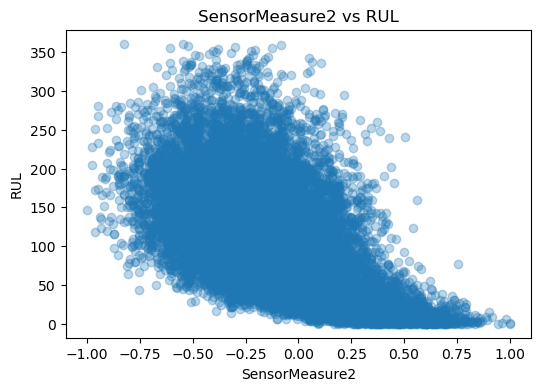

In [12]:
feature = "SensorMeasure2"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

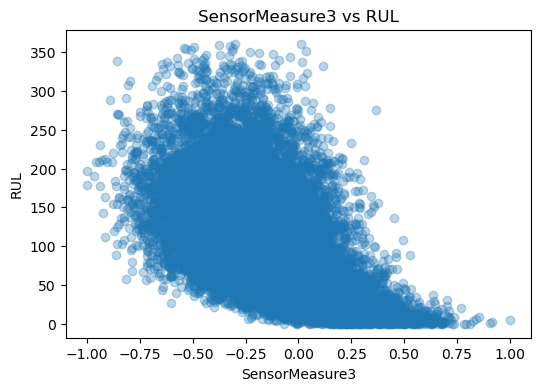

In [13]:
feature = "SensorMeasure3"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

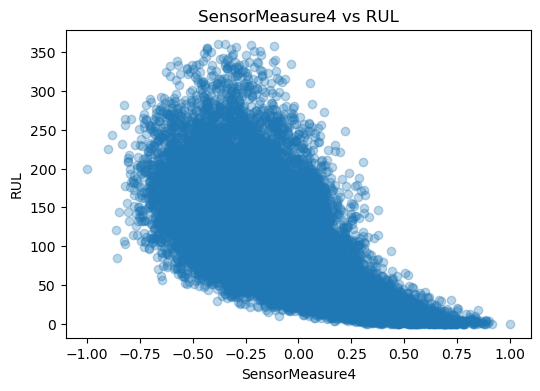

In [14]:
feature = "SensorMeasure4"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

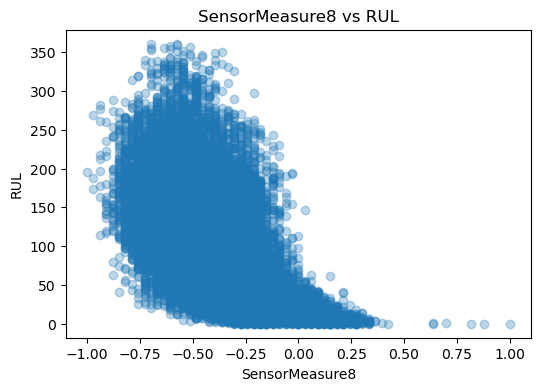

In [15]:
feature = "SensorMeasure8"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

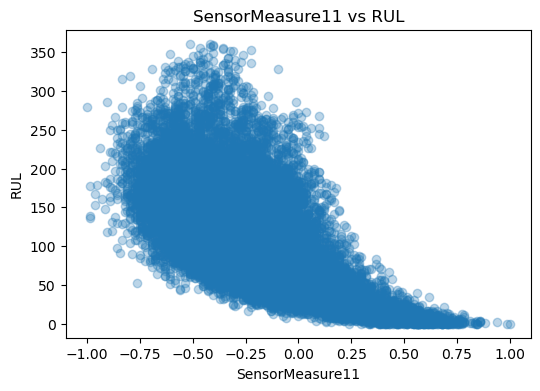

In [16]:
feature = "SensorMeasure11"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

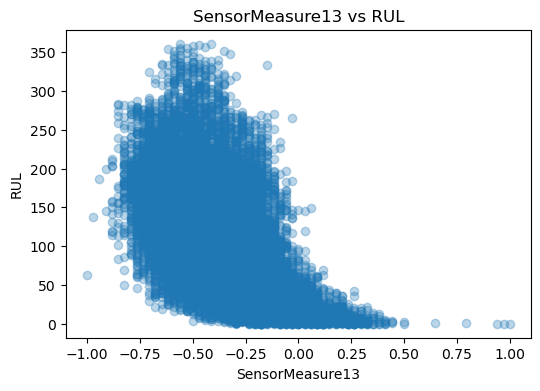

In [17]:
feature = "SensorMeasure13"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

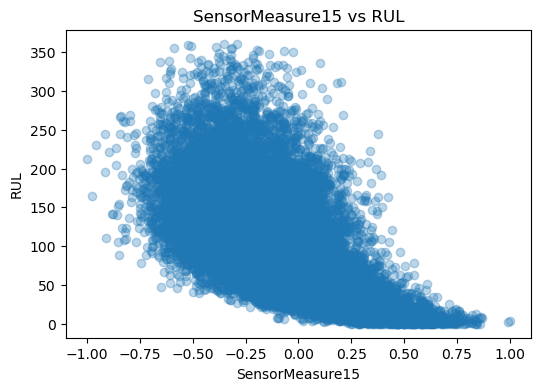

In [18]:
feature = "SensorMeasure15"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

These graphs shows clear negative relationship. As SensorMeasure increases, the RUL decreases. This means higher sensor values indicate the engine is near to failure.

Low sensor values having RUL is very spread out (from low to high). This means when the sensor value is low, it’s hard to predict how much life is left.

High sensor values havingRUL is mostly very low and tightly grouped. This means when the sensor value is high, the machine is almost about to fail.

Final conclusion:
SensorMeasure2,SensorMeasure3, SensorMeasure4,SensorMeasure8,SensorMeasure11,SensorMeasure13 and SensorMeasure15 are a good indicator of machine health — higher values strongly suggest the engine is near to the end of its life.

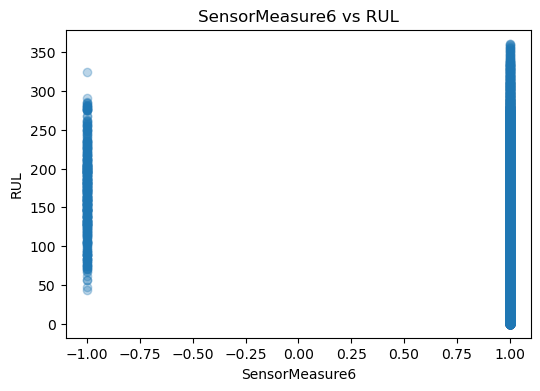

In [19]:
feature = "SensorMeasure6"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

There are only two sensor values, approximately -1 and +1. This tells that SensorMeasure6 is likely binary rather than continuous.

There is no clear relation with RUL. For both values (-1 and +1), the RUL ranges from low to high, meaning both sensor states can occur at any point in the engine's remaining life.

The vertical line pattern  at -1 and +1, tells that the sensor does not change gradually but instead switches between two values.

conclusion:
SensorMeasure6 is not a strong predictor of RUL. It does not show a clear relationship with machine life, so it may not be very useful alone for prediction.

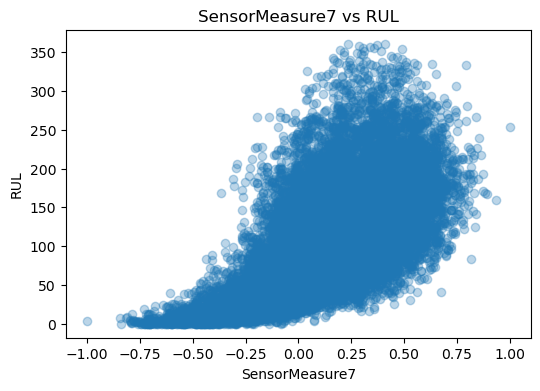

In [20]:
feature = "SensorMeasure7"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

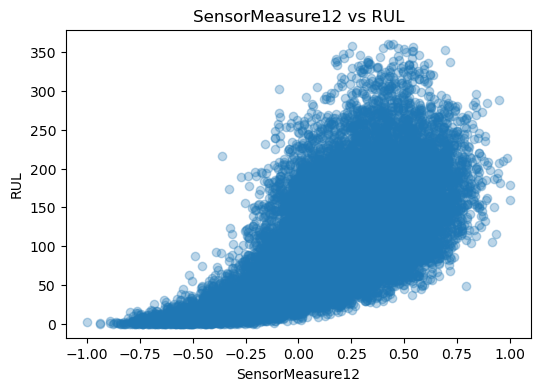

In [21]:
feature = "SensorMeasure12"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

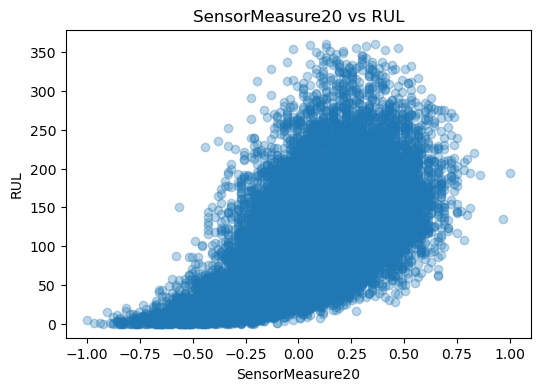

In [22]:
feature = "SensorMeasure20"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

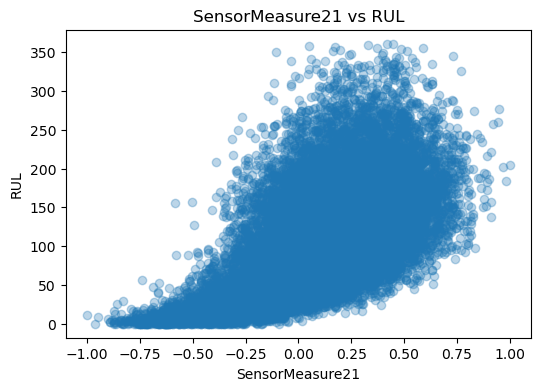

In [23]:
feature = "SensorMeasure21"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

These graphs shows positive relationship. As SensorMeasure21 increases, the RUL also increases. This means higher sensor values indicate the engine has more life remaining.

Low sensor values having RUL is mostly low. This means when the sensor value is low, the machine is closer to failure.

Middle to high values having RUL increases but is spread out. This means there is a trend, but it is not perfectly precise as some variability exists.

The spread increases as values go up. This shows increasing uncertainty at higher sensor values like how much life is left.

Conclusion:
SensorMeasure21 is a useful predictor of RUL. It shows a positive trend, so higher values generally mean the engine is healthier, though predictions have more variation at the higher end.

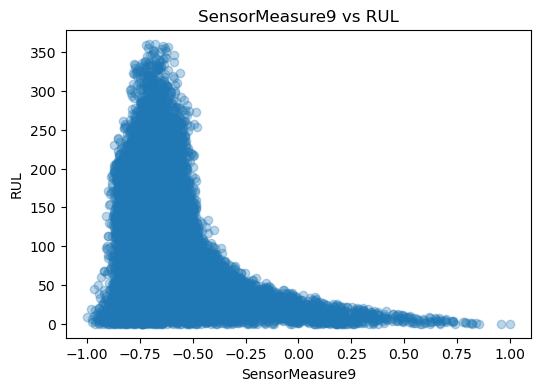

In [24]:
feature = "SensorMeasure9"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

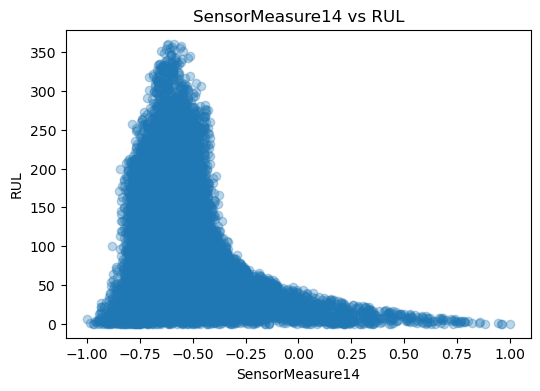

In [25]:
feature = "SensorMeasure14"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

These graphs strong negative relationship. As SensorMeasure increases, RUL decreases sharply, meaning higher sensor values indicate the engines is near to failure.

Low sensor values having  RUL is very high and widely spread (up to ~350). This means when the sensor value is low, the engine can have a lot of life left, but the exact value is uncertain.

High sensor values having RUL is almost always near 0. This means high sensor values strongly indicate immediate failure.


The graph shows a wide spread on the left that becomes very narrow on the right. This shows that prediction becomes more certain as the sensor value increases.

conclusion:
SensorMeasure9 and SensorMeasure14 are partially useful — it is weak for predicting higher RUL but strong for identifying when the machine is close to failure.

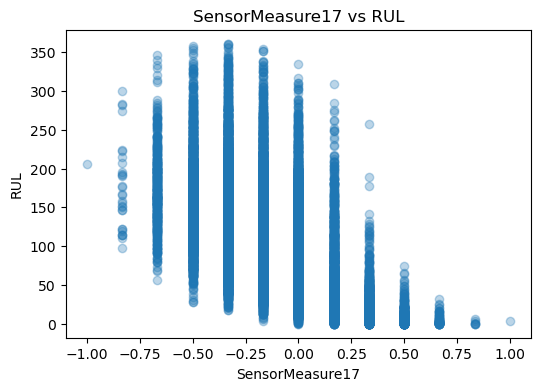

In [26]:
feature = "SensorMeasure17"   
plt.figure(figsize=(6,4))
plt.scatter(df_train[feature], df_train["RUL"], alpha=0.3)
plt.ylabel("RUL")
plt.xlabel(feature)
plt.title(f"{feature} vs RUL")
plt.show()

The scatter plot shows how SensorMeasure17 changes as the engine approaches failure (RUL decreases). The points form a downward pattern, meaning that when the sensor value increases, the remaining useful life generally decreases. This indicates a negative relationship between the sensor and machine health.

However, the points are widely spread vertically at many sensor values. For the same SensorMeasure17 reading, the RUL can still vary a lot (from very low to very high). This large spread means the sensor cannot accurately predict the exact RUL on its own.

Conclusion:
SensorMeasure17 contains useful information about degradation and failure trends, but it is not one of the strongest predictors. It is best used together with other sensors to improve RUL prediction accuracy.

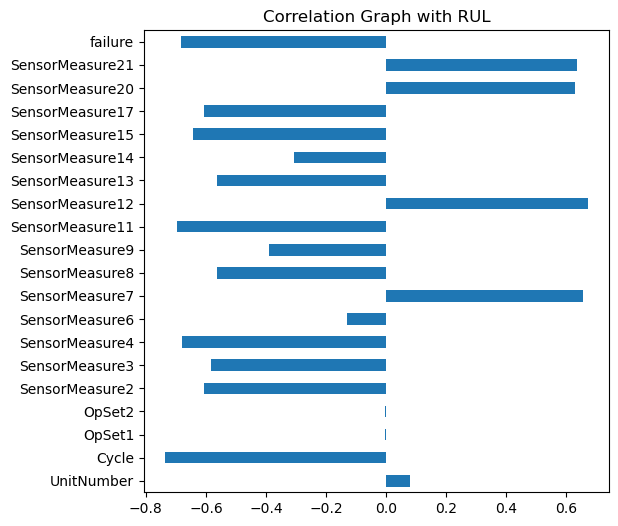

In [27]:
corr = df_train.corr()["RUL"]
corr.drop("RUL").plot(kind="barh", figsize=(6,6))
plt.title("Correlation Graph with RUL")
plt.show()

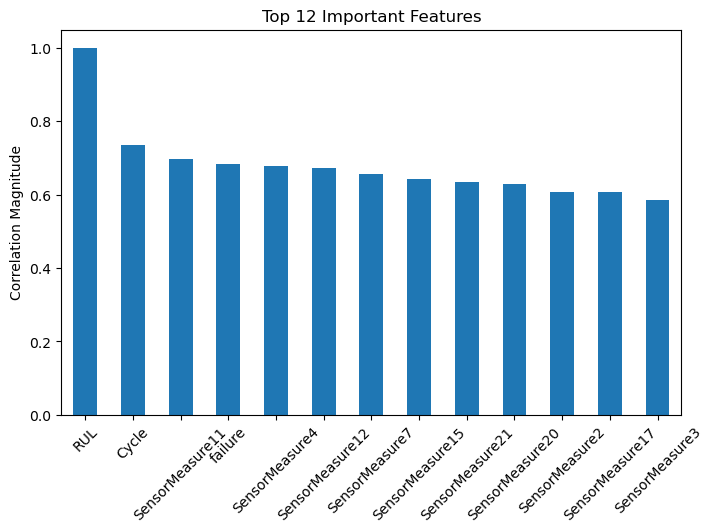

In [28]:
top_features = corr.abs().sort_values(ascending=False).head(13)
plt.figure(figsize=(8,5))
top_features.plot(kind='bar')
plt.title("Top 12 Important Features")
plt.ylabel("Correlation Magnitude")
plt.xticks(rotation=45)
plt.show()

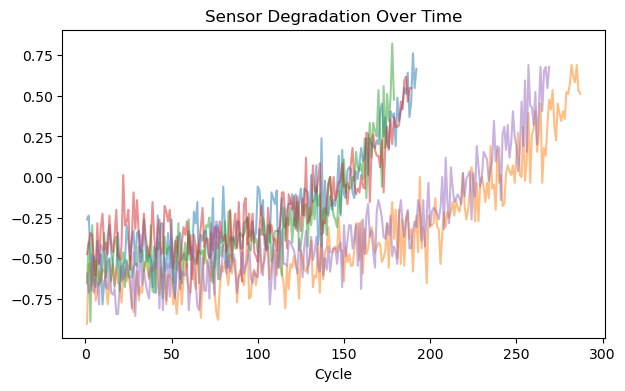

In [34]:
feature = "SensorMeasure11"
plt.figure(figsize=(7,4))
for unit in df_train["UnitNumber"].unique()[:5]: 
    temp = df_train[df_train["UnitNumber"] == unit]
    plt.plot(temp["Cycle"], temp[feature], alpha=0.5)

plt.xlabel("Cycle")
plt.title(f"Sensor Degradation Over Time")
plt.show()

In [30]:

df = pd.read_csv("train_cleaned_data.csv")
X = df.drop(columns=["UnitNumber", "RUL"])  
y = df["RUL"]                               


In [31]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [32]:
model = RandomForestRegressor(n_estimators=100,max_depth=10,random_state=42)

In [33]:
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
error = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", error)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R^2 Score:", r2)

Mean Absolute Error: 25.24239948677052
Mean Squared Error: 1269.0529132117604
R^2 Score: 0.7222346639361256


In [35]:
df.head()

,UnitNumber,Cycle,OpSet1,OpSet2,SensorMeasure2,SensorMeasure3,SensorMeasure4,SensorMeasure6,SensorMeasure7,SensorMeasure8,SensorMeasure9,SensorMeasure11,SensorMeasure12,SensorMeasure13,SensorMeasure14,SensorMeasure15,SensorMeasure17,SensorMeasure20,SensorMeasure21,RUL
0,1,1,-0.0007,-0.0004,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,191
1,1,2,0.0019,-0.0003,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,190
2,1,3,-0.0043,0.0003,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,189
3,1,4,0.0007,0.0000,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,187


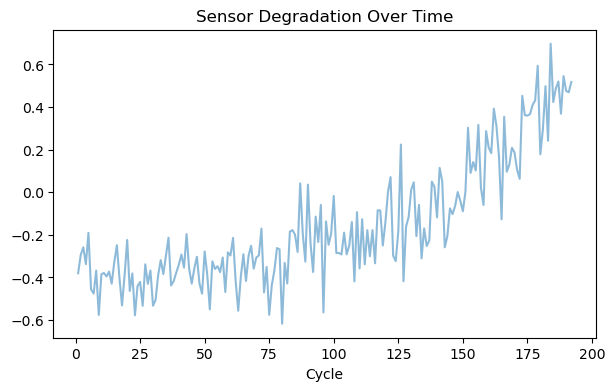

In [50]:
feature = "SensorMeasure4"
plt.figure(figsize=(7,4))
for unit in df_train["UnitNumber"].unique()[:1]: 
    temp = df_train[df_train["UnitNumber"] == unit]
    plt.plot(temp["Cycle"], temp[feature], alpha=0.5)

plt.xlabel("Cycle")
plt.title(f"Sensor Degradation Over Time")
plt.show()